# Part 2: Feature Engineering & Exploratory Data Analysis (EDA)
This notebook engineers numerical metrics out of string components and visualizes key analytical trends within the content distribution.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# sns.set_style("whitegrid")
# plt.rcParams["figure.figsize"] = (12, 6)

df = pd.read_csv("netflix_cleaned.csv")

In [2]:
# Split duration into numeric value and unit
df["duration_num"] = df["duration"].astype(str).str.extract(r"(\d+)").astype(float)
df["duration_unit"] = df["duration"].astype(str).str.extract(r"([A-Za-z]+)")

# Fill missing duration numbers with median
df["duration_num"] = df["duration_num"].fillna(df["duration_num"].median())

# Create binary features
df["is_movie"] = (df["type"].str.lower() == "movie").astype(int)
df["is_tv_show"] = (df["type"].str.lower() == "tv show").astype(int)



In [3]:
# Create metadata counts
df["genre_count"] = df["listed_in"].fillna("").apply(lambda x: len([i.strip() for i in x.split(",") if i.strip() != ""]))#counts how many genres a title belongs to
df["cast_count"] = df["cast"].fillna("").apply(lambda x: len([i.strip() for i in x.split(",") if i.strip() != ""]))#counts how many actors are listed.
df["country_count"] = df["country"].fillna("").apply(lambda x: len([i.strip() for i in x.split(",") if i.strip() != ""]))#how many countries worked together to make the movie or TV show.

# Primary groupings
df["primary_country"] = df["country"].fillna("").apply(lambda x: x.split(",")[0].strip() if x else "Unknown")#assign one main country to each title, making grouping and plotting easier.
df["primary_genre"] = df["listed_in"].fillna("").apply(lambda x: x.split(",")[0].strip() if x else "Unknown")#main genre of the title

# Title length features
df["title_length"] = df["title"].fillna("").apply(len)
df["title_word_count"] = df["title"].fillna("").apply(lambda x: len(x.split()))
                                       

In [ ]:

plt.figure(figsize=(8, 5))
type_counts=df["type"].value_counts().reset_index() #reset index convert series to dataframe
type_counts.columns=["Type","Count"]
Fig=px.bar(type_counts,x="Type",y="Count",title="Content Type Distribution",labels={"Type":"Type of Content","Count":"Number of Titles"},
           text="Count",color="Type")
Fig.update_layout(template="plotly_dark")
Fig.show()


<Figure size 800x500 with 0 Axes>

In [10]:
# Trend over time
# added_trend = df.groupby("added_year").size().reset_index(name="count").sort_values("added_year")
# plt.figure(figsize=(12, 5))
# sns.lineplot(data=added_trend, x="added_year", y="count", marker="o")
# plt.title("Content Added Over Years")
# plt.show()

added_trends=df.groupby("added_year").size().reset_index(name="Count")
Fig=px.line(added_trends,x="added_year",y="Count",title="Content Added Over Years",
            labels={"added_year":"Year","Count":"Number of Titles"},markers=True)
Fig.update_layout(template="plotly_dark")
Fig.show()

C:\Users\shubh\AppData\Local\Temp\ipykernel_24228\3060809988.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




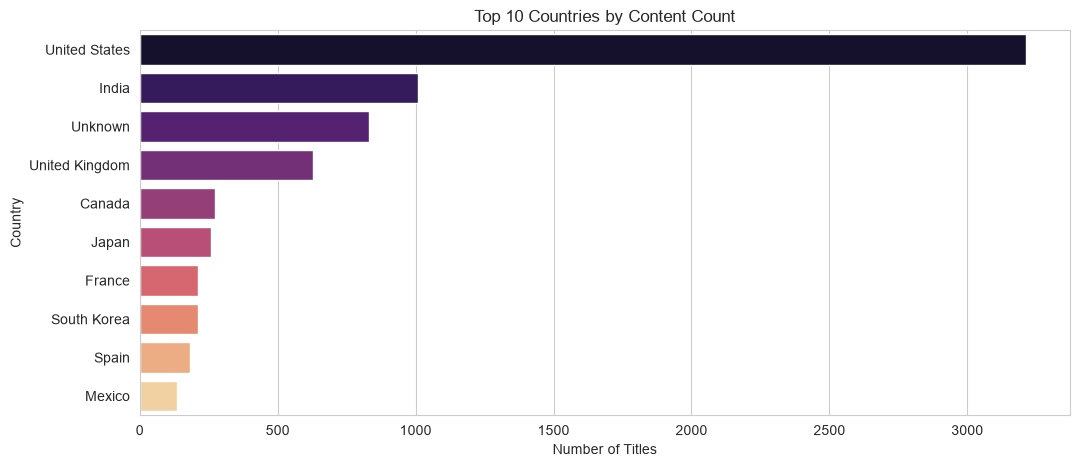

C:\Users\shubh\AppData\Local\Temp\ipykernel_24228\3060809988.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




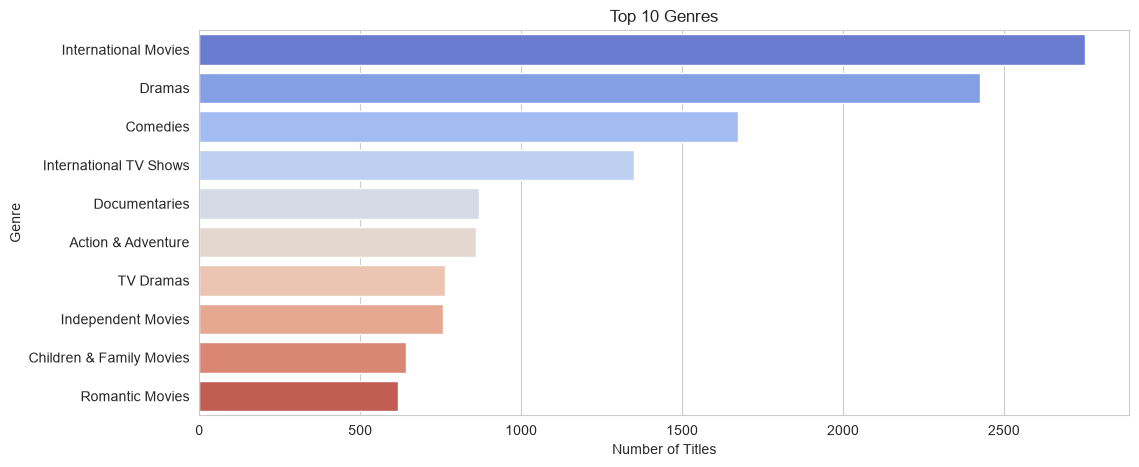

In [11]:
# Top Countries and Top Genres
top_countries = df["primary_country"].value_counts().head(10)
plt.figure(figsize=(12, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="magma")
plt.title("Top 10 Countries by Content Count")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()



genre_series = df["listed_in"].dropna().str.split(",").explode().str.strip() #explode create separate row for each genre
top_genres = genre_series.value_counts().head(10)
plt.figure(figsize=(12, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="coolwarm")
plt.title("Top 10 Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()



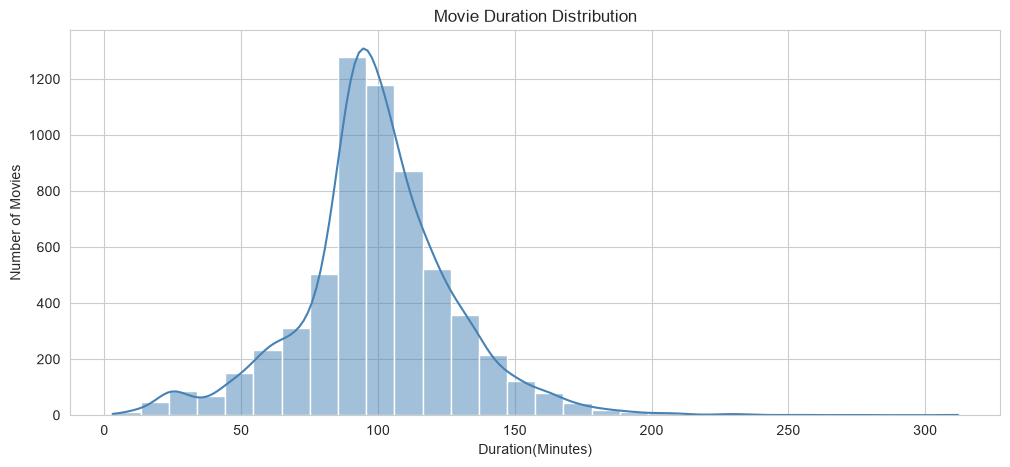

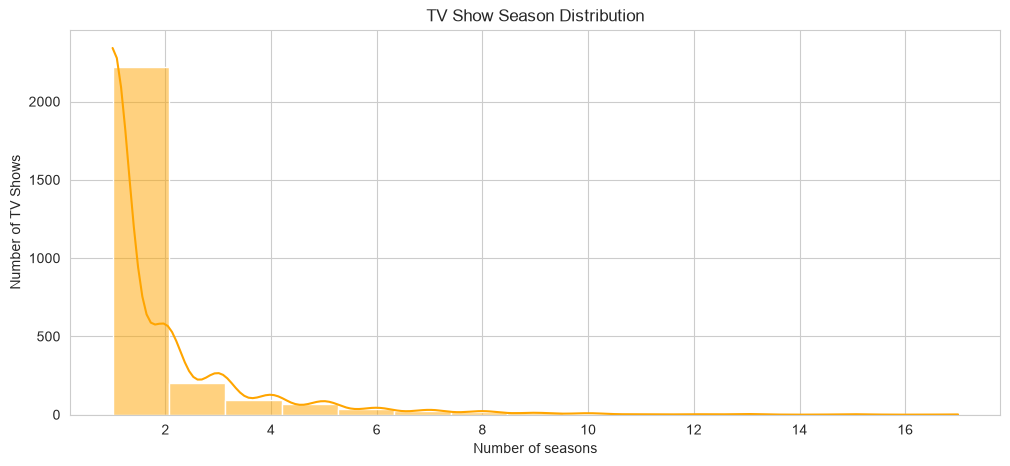

In [ ]:
# Duration analyses
movie_df = df[df["duration_unit"].str.contains("min", case=False, na=False)].copy()#case=False → Ignores uppercase/lowercase (min, MIN, Min all match).
# na),=False → If a value is missing NaN treat it as False instead of causing an error.
show_df = df[df["duration_unit"].str.contains("Season", case=False, na=False)].copy()

plt.figure(figsize=(12, 5))
sns.histplot(movie_df["duration_num"], bins=30, kde=True, color="steelblue")
plt.title("Movie Duration Distribution")
plt.xlabel("Duration(Minutes)")
plt.ylabel("Number of Movies")
plt.show()


plt.figure(figsize=(12, 5))
sns.histplot(show_df["duration_num"], bins=15, kde=True, color="orange")
plt.title("TV Show Season Distribution")
plt.xlabel("Number of seasons")
plt.ylabel("Number of TV Shows")
plt.show()

df.to_csv("netflix_featured.csv", index=False)